In [1]:
import scipy
import numpy as np
import matplotlib.pyplot as plt

In [2]:
integrated_function = lambda x: 4/(1+x**2)


In [3]:
def generate_nodes(start,end,m):
    number_of_nodes = 2**m +1
    return np.linspace(start,end,number_of_nodes)

In [4]:
def midpoint_rule(f, a, b, m):
    n = 2**m+1
    dx = (b - a) / n
    x_mid = np.linspace(a + dx/2, b - dx/2, n)
    return np.sum(f(x_mid)) * dx

In [17]:
START = 0
END = 1
results_trapezoid = []
results_simpson = []
results_midpoint = []
for m in range(1,15):
    x_s = generate_nodes(START,END,m)
    y_s = integrated_function(x_s)
    results_trapezoid.append(scipy.integrate.trapezoid(y_s,x_s))
    results_simpson.append(scipy.integrate.simpson(y_s,x_s))
    results_midpoint.append(midpoint_rule(integrated_function,START,END,m))


In [19]:

results_midpoint = np.array(results_midpoint)
results_simpson = np.array(results_simpson)
results_trapezoid = np.array(results_trapezoid)

In [15]:
results_legendre = []
for m in range(1,15):
    n = 2**m+1
    #coefficients = np.array([0]*n + [1])
    #legendre_points = np.polynomial.legendre.legroots(coefficients)
    result = scipy.integrate.fixed_quad(integrated_function,START,END,n=n)
    results_legendre.append(result[0])
results_legendre = np.array(results_legendre)
print(results_legendre)

[3.14106814 3.14159264 3.14159265 3.14159265 3.14159265 3.14159265
 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265
 3.14159265 3.14159265]


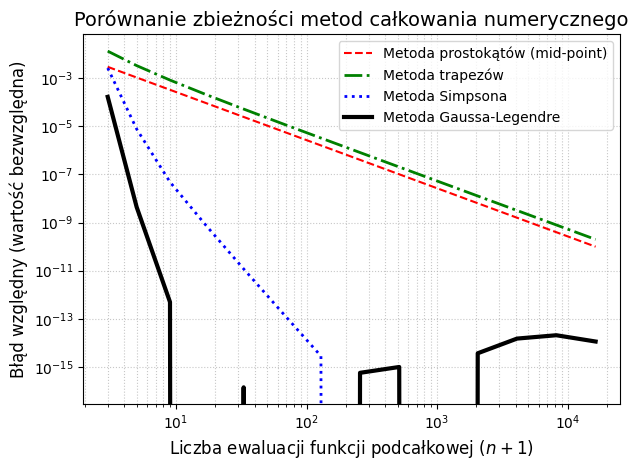

In [22]:
results_legendre = np.array(results_legendre)

n_s = [2**m+1 for m in range(1,15)]
midpoint_error = np.abs(results_midpoint-np.pi)/np.pi
trapezoid_error = np.abs(results_trapezoid-np.pi)/np.pi
simpson_error = np.abs(results_simpson-np.pi)/np.pi
legendre_error = np.abs(results_legendre-np.pi)/np.pi

plt.loglog(n_s, midpoint_error, 'r--', linewidth=1.5, label='Metoda prostokątów (mid-point)')
plt.loglog(n_s, trapezoid_error, 'g-.', linewidth=2, label='Metoda trapezów')
plt.loglog(n_s, simpson_error, 'b:', linewidth=2, label='Metoda Simpsona')
plt.loglog(n_s, legendre_error, 'k-', linewidth=3, label='Metoda Gaussa-Legendre')

# Dodanie punktów dla lepszej widoczności (opcjonalnie, dla małych n)
#plt.plot(n_s[:10], midpoint_error[:10], 'ro', markersize=4)
#plt.plot(n_s_legendre[:15], legendre_error[:15], 'ks', markersize=4)

# Konfiguracja estetyki wykresu
plt.title('Porównanie zbieżności metod całkowania numerycznego', fontsize=14)
plt.xlabel('Liczba ewaluacji funkcji podcałkowej ($n+1$)', fontsize=12)
plt.ylabel('Błąd względny (wartość bezwzględna)', fontsize=12)

plt.legend(loc='upper right', fontsize=10)
plt.grid(True, which="both", linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [24]:

H_MIN_CALCULATED = 9.123695225180451e-09

In [25]:
min_idx_s = np.array([np.argmin(array) for array in [midpoint_error, trapezoid_error, simpson_error,legendre_error]])
m_min = min_idx_s + 1  # Ponieważ pętla zaczyna się od m=1
n_min = 2 ** m_min
h_min = 1 / n_min
for m, h in zip(m_min, h_min):
    print(f"Błąd metody trapezów przestaje maleć dla m = {m}")
    print(f"Odpowiada to krokowi h_min = {h}")
    print()


def calculate_empirical_rank(errors):
    # Wybieramy pierwsze 5 kroków, gdzie błąd metody wyraźnie przeważa nad numerycznym
    # Dzielimy błąd z kroku m przez błąd z kroku m+1
    rzędy = np.log2(errors[0:5] / errors[1:6])
    return np.mean(rzędy)


print("--- Porównanie rzędów zbieżności ---")
print(f"Prostokąty: empiryczny = {calculate_empirical_rank(midpoint_error):.2f}")
print(f"Trapezy:    empiryczny = {calculate_empirical_rank(trapezoid_error):.2f}")
print(f"Simpson:    empiryczny = {calculate_empirical_rank(simpson_error):.2f}")
print(f"Legendre:    empiryczny = {calculate_empirical_rank(simpson_error):.2f}")

Błąd metody trapezów przestaje maleć dla m = 14
Odpowiada to krokowi h_min = 6.103515625e-05

Błąd metody trapezów przestaje maleć dla m = 14
Odpowiada to krokowi h_min = 6.103515625e-05

Błąd metody trapezów przestaje maleć dla m = 8
Odpowiada to krokowi h_min = 0.00390625

Błąd metody trapezów przestaje maleć dla m = 4
Odpowiada to krokowi h_min = 0.0625

--- Porównanie rzędów zbieżności ---
Prostokąty: empiryczny = 1.77
Trapezy:    empiryczny = 2.00
Simpson:    empiryczny = 6.75
Legendre:    empiryczny = 6.75
